In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Point this at wherever you uploaded the project on your Drive:
    PROJECT_ROOT = '/content/drive/MyDrive/NLP PROJECT/Neural_Search_Engine-main'
    sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    # The from-scratch model only needs torch (already installed in Colab).
    # No transformers / tokenizers / safetensors / sentence-transformers.
else:
    PROJECT_ROOT = os.path.abspath('..')
    sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)

import torch
print('PyTorch  :', torch.__version__)
print('CUDA     :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU      :', torch.cuda.get_device_name(0))
    print('VRAM     :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Mounted at /content/drive
PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [8]:
# import json

# def load_json(path):
#     with open(path, encoding='utf-8') as f:
#         return json.load(f)

# chunks      = load_json('data/processed/jurafsky_chunks_v2.json')
# train_pairs = load_json('data/processed/train_pairs.json')
# val_pairs   = load_json('data/processed/val_pairs.json')

# print(f'Corpus chunks : {len(chunks)}')
# print(f'Train pairs   : {len(train_pairs)}')
# print(f'Val pairs     : {len(val_pairs)}')

Corpus chunks : 1410
Train pairs   : 2322
Val pairs     : 258


In [2]:
import json, random

def load_json(p):
    with open(p, encoding='utf-8') as f:
        return json.load(f)

jur  = load_json('data/processed/train_pairs.json')
comb = load_json('data/processed/train_pairs_combined.json')
wiki = [p for p in comb if str(p.get('positive_id', '')).startswith('wiki')]
random.seed(42)
train_pairs = jur + random.sample(wiki, len(jur))   # ~50/50 Jurafsky : wiki
random.shuffle(train_pairs)

val_pairs = load_json('data/processed/val_pairs.json')          # keep val IN-DOMAIN (Jurafsky)
chunks    = load_json('data/processed/jurafsky_chunks_v2.json')
print(f'Mixed train: {len(train_pairs)} (Jurafsky {len(jur)} + wiki {len(jur)})  |  Val (Jurafsky): {len(val_pairs)}')

Mixed train: 4644 (Jurafsky 2322 + wiki 2322)  |  Val (Jurafsky): 258


In [3]:
p = train_pairs[0]
print(f"Example query    : {p['query']}")
print(f"Example positive : {p['positive_text'][:120]}")
print(f"Example negative : {p['negative_text'][:120]}")

Example query    : Explain Artificial intelligence engineering.
Example positive : Security Security is a critical consideration in AI engineering, particularly as AI systems become increasingly integrat
Example negative : The stricture is formed in such a way that the airstream causes a repeating pattern of opening and closing of the soft a


In [4]:
from src.tokenizer import BPETokenizer
from src.train import build_tokenizer_from_pairs

CHECKPOINT = 'checkpoints'
os.makedirs(CHECKPOINT, exist_ok=True)

# Train the from-scratch BPE tokenizer on the corpus + all training-pair text
# (queries, positives, negatives) so it covers every word the model will see.
tokenizer = build_tokenizer_from_pairs(chunks, train_pairs, vocab_size=8000)
tokenizer.save(f'{CHECKPOINT}/tokenizer.json')
print('Tokenizer vocab size:', tokenizer.vocab_size)

# Quick sanity check
ids = tokenizer.encode('What is a bigram language model?', max_length=32)
print('Example encode:', ids[:12], '...')
print('Decoded back  :', tokenizer.decode(ids))

[BPE] unique words=49468  base chars=1064  target merges=6934
[BPE]   learned 1000/6934 merges
[BPE]   learned 2000/6934 merges
[BPE]   learned 3000/6934 merges
[BPE]   learned 4000/6934 merges
[BPE]   learned 5000/6934 merges
[BPE]   learned 6000/6934 merges
[BPE] done. vocab_size=8000  merges=6934
Tokenizer saved -> checkpoints/tokenizer.json  (vocab_size=8000)
Tokenizer vocab size: 8000
Example encode: [1586, 1104, 1090, 3513, 1287, 1325, 1445] ...
Decoded back  : what is a bigram language model ?


In [5]:
from src.model import BiEncoder, EncoderConfig
from src.train import Trainer

# --- Hyperparameters (see the table at the top) ---
D_MODEL       = 256
N_LAYERS      = 4
N_HEADS       = 4
DOC_MAX_LEN   = 256   # documents (chunks) are long
QUERY_MAX_LEN = 64    # queries are short
BATCH_SIZE    = 64
EPOCHS        = 20
LR            = 3e-4
TEMPERATURE   = 0.05
CHECKPOINT    = 'checkpoints'

config = EncoderConfig(
    vocab_size = tokenizer.vocab_size,
    d_model    = D_MODEL,
    n_layers   = N_LAYERS,
    n_heads    = N_HEADS,
    d_ff       = D_MODEL * 4,
    max_len    = DOC_MAX_LEN,
)
model = BiEncoder(config)
print(f'Model parameters: {model.num_parameters():,}')

Model parameters: 5,207,552


In [6]:
trainer = Trainer(
    model         = model,
    tokenizer     = tokenizer,
    train_pairs   = train_pairs,
    val_pairs     = val_pairs,
    output_dir    = CHECKPOINT,
    query_max_len = QUERY_MAX_LEN,
    doc_max_len   = DOC_MAX_LEN,
    batch_size    = BATCH_SIZE,
    epochs        = EPOCHS,
    lr            = LR,
    temperature   = TEMPERATURE,
)

print('Trainer ready.')
print(f'Batches per epoch : {len(trainer.train_loader)}')
print(f'Total steps       : {len(trainer.train_loader) * EPOCHS}')

Explicit hard negatives: ON
Tokenizer saved -> checkpoints/tokenizer.json  (vocab_size=8000)
Trainer ready.
Batches per epoch : 73
Total steps       : 1460


In [7]:
history = trainer.fit()

Training on: cuda   model params: 5,207,552
Train batches/epoch: 73   Total steps: 1460

  Epoch 1 | step   73/73 | loss 3.8556 | avg 4.4362 | lr 1.50e-04
Epoch 1/20 | train_loss=4.4362  val_loss=3.9058  time=25.4s  saved best -> best.pt
  Epoch 2 | step   73/73 | loss 3.1657 | avg 3.9111 | lr 3.00e-04
Epoch 2/20 | train_loss=3.9111  val_loss=3.7076  time=25.8s  saved best -> best.pt
  Epoch 3 | step   73/73 | loss 2.5192 | avg 3.4197 | lr 2.83e-04
Epoch 3/20 | train_loss=3.4197  val_loss=3.3118  time=27.6s  saved best -> best.pt
  Epoch 4 | step   73/73 | loss 1.5778 | avg 2.3078 | lr 2.67e-04
Epoch 4/20 | train_loss=2.3078  val_loss=3.0965  time=29.9s  saved best -> best.pt
  Epoch 5 | step   73/73 | loss 1.1824 | avg 1.3568 | lr 2.50e-04
Epoch 5/20 | train_loss=1.3568  val_loss=3.2714  time=28.9s
  Epoch 6 | step   73/73 | loss 0.5527 | avg 0.7861 | lr 2.33e-04
Epoch 6/20 | train_loss=0.7861  val_loss=3.4446  time=28.2s
  Epoch 7 | step   73/73 | loss 0.2601 | avg 0.4855 | lr 2.17e-

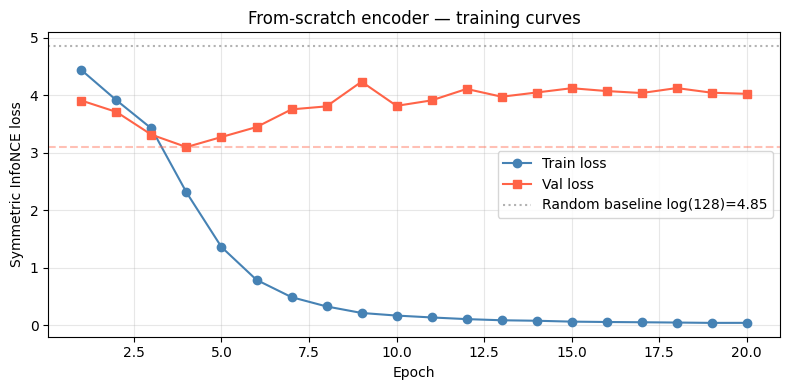

Best val loss : 3.0965
Random loss   : 4.8520   (untrained reference)
Improvement   : 1.7555


In [8]:
import math
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(history['train_loss']) + 1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_x, history['train_loss'], marker='o', label='Train loss', color='steelblue')
ax.plot(epochs_x, history['val_loss'],   marker='s', label='Val loss',   color='tomato')
ax.axhline(y=min(history['val_loss']), linestyle='--', color='tomato', alpha=0.4)

n_candidates = BATCH_SIZE * (2 if trainer.use_negatives else 1)
random_loss = math.log(n_candidates)
ax.axhline(y=random_loss, linestyle=':', color='grey', alpha=0.6,
           label=f'Random baseline log({n_candidates})={random_loss:.2f}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Symmetric InfoNCE loss')
ax.set_title('From-scratch encoder — training curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('checkpoints/training_curves.png', dpi=150)
plt.show()

print(f'Best val loss : {min(history["val_loss"]):.4f}')
print(f'Random loss   : {random_loss:.4f}   (untrained reference)')
print(f'Improvement   : {random_loss - min(history["val_loss"]):.4f}')

In [11]:
import pandas as pd

log_df = pd.read_csv('checkpoints/training_log.csv')
print(log_df.to_string(index=False))

 epoch  step  train_loss  val_loss       lr
     1    73    4.436201  3.905833 0.000150
     2   146    3.911102  3.707626 0.000300
     3   219    3.419701  3.311781 0.000283
     4   292    2.307768  3.096526 0.000267
     5   365    1.356801  3.271430 0.000250
     6   438    0.786124  3.444625 0.000233
     7   511    0.485544  3.752258 0.000217
     8   584    0.323873  3.804761 0.000200
     9   657    0.210386  4.233858 0.000183
    10   730    0.164994  3.813661 0.000167
    11   803    0.132340  3.908819 0.000150
    12   876    0.103345  4.107770 0.000133
    13   949    0.083293  3.972611 0.000117
    14  1022    0.074800  4.045876 0.000100
    15  1095    0.059596  4.120699 0.000083
    16  1168    0.053092  4.071168 0.000067
    17  1241    0.048670  4.036689 0.000050
    18  1314    0.043600  4.123192 0.000033
    19  1387    0.037661  4.042303 0.000017
    20  1460    0.038311  4.022794 0.000000


In [12]:
import os
for fname in sorted(os.listdir('checkpoints')):
    fpath = os.path.join('checkpoints', fname)
    if os.path.isfile(fpath):
        print(f'  {fname:<26} {os.path.getsize(fpath) / 1e6:.2f} MB')
model_loaded = BiEncoder.load('checkpoints/best.pt')
model_loaded.eval()
print('\nReloaded best.pt — parameters:', f'{model_loaded.num_parameters():,}')

  best.pt                    21.11 MB
  evaluation_results.png     0.04 MB
  final.pt                   21.11 MB
  mrr_by_query_type.png      0.04 MB
  pair_length_dist.png       0.03 MB
  tokenizer.json             0.26 MB
  training_curves.png        0.06 MB
  training_log.csv           0.00 MB

Reloaded best.pt — parameters: 5,207,552
